
# NN Background

**Neural networks (NNs) are a collection of nested functions that are
executed on some input data. These functions are defined by *parameters*
(consisting of weights and biases), which in PyTorch are stored in
tensors.**

**Training a NN happens in two steps:**

**Forward Propagation**: In forward prop, the NN makes its best guess
about the correct output. It runs the input data through each of its
functions to make this guess.

**Backward Propagation**: In backprop, the NN adjusts its parameters
proportionate to the error in its guess. It does this by traversing
backwards from the output, collecting the derivatives of the error with
respect to the parameters of the functions (*gradients*), and optimizing
the parameters using gradient descent. 

For a more detailed walkthrough
of backprop, check out this [video from
3Blue1Brown] (https://www.youtube.com/watch?v=tIeHLnjs5U8).

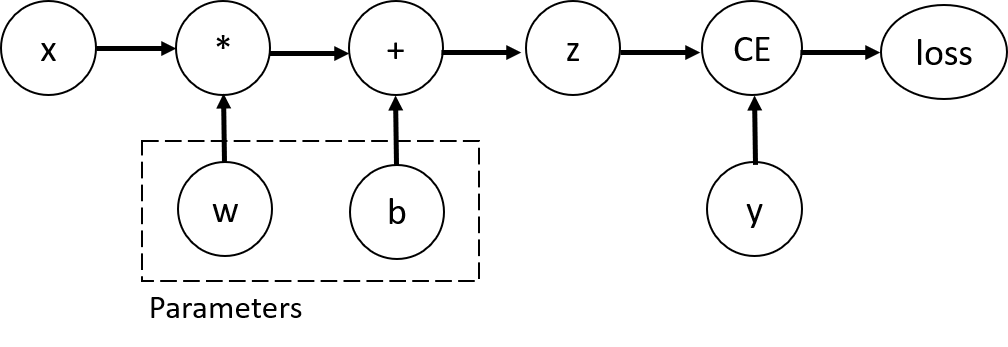

## Using PyTorch

Let's take a look at a single training step.
For this example, we load a pretrained resnet18 model from ``torchvision``.
We create a random data tensor to represent a single image with 3 channels, and height & width of 64,
and its corresponding ``label`` initialized to some random values.



``torchvision`` **Key Components:**
 - **Datasets**: Provides standard computer vision loaders like ImageNet, CIFAR-10, and MNIST.
 - **Models**: Includes definitions for classic and modern architectures (like ResNet, VGG, and MobileNet) with pre-trained weights.
 - **Transforms**: Offers common preprocessing and data augmentation operations for images, videos, and bounding boxes.

In [1]:
import torch, torchvision
from torch import nn

In [3]:
from torchvision.models import resnet18, ResNet18_Weights

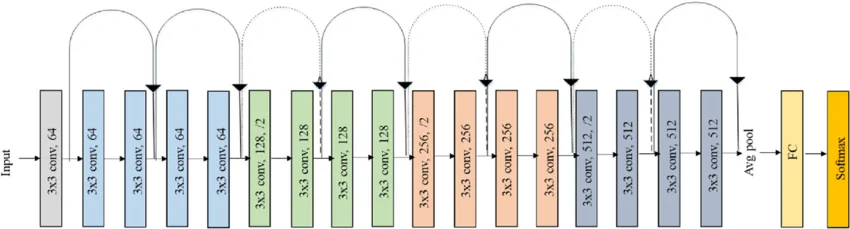

### Download the model and save the model into path to be used later without downloading

The code snippet ``model = resnet18(weights=ResNet18_Weights.DEFAULT)`` initializes a ResNet-18 model pre-loaded with the highest-performing weights available in the PyTorch library.

By using ``ResNet18_Weights.DEFAULT``, PyTorch automatically downloads and applies weights trained on the **ImageNet-1K** dataset (1000 class). 

This configures your network for transfer learning or fine-tuning (seen later), saving you massive amounts of computational time and data requirements compared to training from scratch.

In [4]:
model = resnet18(weights=ResNet18_Weights.DEFAULT)
print(model)

PATH = r'D:\Teaching\UL\AI\Lab\resnetModel\resnet18.pth'
#save model parameters in dictionary
torch.save(model.state_dict(), PATH) #state_dict is simply a Python dictionary object that maps each layer to its parameter tensor  (such as weights and biases).

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

**Notice** the ''out_features=1000''

### Inspecting Model Weights or Tensors
As the ``.pt`` file contains a model's state dictionary (weights and biases), you can loop through the dictionary keys and inspect individual tensor shapesIf your ``.pt`` file contains a model's state dictionary (weights and biases), you can loop through the dictionary keys and inspect individual tensor shapes`.

In [5]:
import torch

state_dict = torch.load(PATH, map_location="cpu")

for key, value in state_dict.items():
  print(f"{key}: {value.shape}")

conv1.weight: torch.Size([64, 3, 7, 7])
bn1.weight: torch.Size([64])
bn1.bias: torch.Size([64])
bn1.running_mean: torch.Size([64])
bn1.running_var: torch.Size([64])
bn1.num_batches_tracked: torch.Size([])
layer1.0.conv1.weight: torch.Size([64, 64, 3, 3])
layer1.0.bn1.weight: torch.Size([64])
layer1.0.bn1.bias: torch.Size([64])
layer1.0.bn1.running_mean: torch.Size([64])
layer1.0.bn1.running_var: torch.Size([64])
layer1.0.bn1.num_batches_tracked: torch.Size([])
layer1.0.conv2.weight: torch.Size([64, 64, 3, 3])
layer1.0.bn2.weight: torch.Size([64])
layer1.0.bn2.bias: torch.Size([64])
layer1.0.bn2.running_mean: torch.Size([64])
layer1.0.bn2.running_var: torch.Size([64])
layer1.0.bn2.num_batches_tracked: torch.Size([])
layer1.1.conv1.weight: torch.Size([64, 64, 3, 3])
layer1.1.bn1.weight: torch.Size([64])
layer1.1.bn1.bias: torch.Size([64])
layer1.1.bn1.running_mean: torch.Size([64])
layer1.1.bn1.running_var: torch.Size([64])
layer1.1.bn1.num_batches_tracked: torch.Size([])
layer1.1.conv2.

### Load the model from path

The code snippet ``model = resnet18(weights=None)`` initializes a ResNet-18 convolutional neural network architecture with randomly initialized weights. (https://docs.pytorch.org/vision/0.24/models/generated/torchvision.models.resnet18.html)

In modern versions of PyTorch Torchvision (v0.13+), passing ``weights=None`` explicitely tells the framework to build the model structure from scratch rather than downloading or loading any pre-trained feature weights (like those trained on ImageNet).

This setup is typically used when you want to train the entire network from scratch on a completely custom dataset.(https://docs.pytorch.org/vision/0.24/models/generated/torchvision.models.resnet18.html)

In [5]:
model = resnet18(weights=None) #initializes a ResNet-18 convolutional neural network architecture with randomly initialized weights.
print(model)

# Access the first convolutional layer's weights
print("model.conv1.weight: \n:" , model.conv1.weight)

# Access the final fully connected layer's weights and biases
print("model.fc.weight: \n:" ,model.fc.weight)
print("model.fc.bias: \n:" , model.fc.bias)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [6]:
PATH = r'D:\Teaching\UL\AI\Lab\resnetModel\resnet18.pth'
#LOAD model parameters in dictionary
model.load_state_dict(torch.load(PATH))

print(model)
# Access the first convolutional layer's weights
print("model.conv1.weight: \n:" , model.conv1.weight)

# Access the final fully connected layer's weights and biases
print("model.fc.weight: \n:" , model.fc.weight)
print("model.fc.bias: \n:" , model.fc.bias)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### Change number of features if needed

In [7]:
n_features = 10
model.fc = nn.Linear(model.fc.in_features, n_features)
print("model.fc: \n" , model.fc )
print("\n")
print("model: \n" , model)

# Access the first convolutional layer's weights
print("model.conv1.weight: \n:" , model.conv1.weight)

# Access the final fully connected layer's weights and biases
print("model.fc.weight: \n:" , model.fc.weight)
print("model.fc.bias: \n:" , model.fc.bias)

model.fc: 
 Linear(in_features=512, out_features=10, bias=True)


model: 
 ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1,

## create input data

The code ``torch.rand(1, 3, 64, 64)`` creates a PyTorch tensor filled with random floating-point numbers sampled from a uniform distribution between 0 and 1 (specifically, on the interval \([0, 1)\)). (https://docs.pytorch.org/docs/stable/generated/torch.rand.html)

In machine learning and computer vision applications, this specific syntax is most commonly used to simulate a batch of image data:
- 1: The Batch Size. It generates a batch containing exactly 1 image.
- 3: The number of Channels. This represents the 3 color channels (Red, Green, Blue) of a standard RGB image.
- 64: The Height of the image in pixels.
- 64: The Width of the image in pixels.

In [23]:
inputData = torch.rand(1, 3, 64, 64) # imitating a 3-channel (RGB) image of resolution 64x64
print(inputData.size())
#x= torch.count_nonzero(data, dim=-2)
#print(x)
print(inputData)

torch.Size([1, 3, 64, 64])
tensor([[[[9.5841e-01, 6.0746e-01, 2.8166e-01,  ..., 9.3681e-01,
           6.1917e-01, 2.4135e-01],
          [1.6661e-01, 6.9673e-01, 6.4277e-01,  ..., 1.2155e-01,
           2.6584e-02, 1.4099e-01],
          [5.5063e-01, 5.4008e-01, 3.9730e-02,  ..., 4.8003e-01,
           6.5066e-01, 7.1473e-02],
          ...,
          [6.9182e-01, 5.7999e-01, 1.4790e-01,  ..., 8.3422e-02,
           6.3316e-01, 8.0672e-01],
          [2.4326e-01, 9.4158e-01, 6.8585e-01,  ..., 7.0906e-01,
           7.0271e-01, 3.0782e-01],
          [3.3045e-01, 7.6311e-01, 2.2229e-01,  ..., 6.8798e-01,
           5.2555e-01, 8.8321e-01]],

         [[6.7163e-01, 7.9909e-01, 5.3082e-01,  ..., 6.0547e-01,
           8.3251e-01, 7.6736e-01],
          [9.3180e-01, 7.0346e-02, 3.9334e-01,  ..., 3.4731e-01,
           3.2179e-01, 1.4288e-02],
          [8.0640e-01, 7.2000e-01, 8.1161e-01,  ..., 5.3906e-01,
           7.1333e-01, 6.7825e-01],
          ...,
          [2.6193e-01, 6.2501e-0

## visualize the data:  functions to show an image

img shape: torch.Size([3, 64, 64])


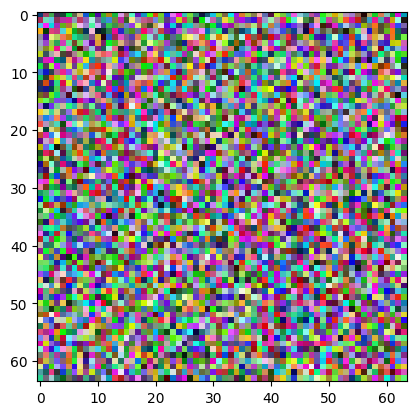

In [9]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import torchvision

# 1. Define the original function (without unnormalization for raw random data)
def Display(img):
    print("img shape:", img.shape)  # Helpful debugging check
    npimg = img.numpy()
    # Transpose from (Channels, Height, Width) to (Height, Width, Channels)
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# 3. Create a grid (make_grid converts a 4D batch into a single 3D image grid)
image = torchvision.utils.make_grid(inputData)

# 4. Display the grid image
Display(image)


## create labels 
- random in this demo
- the **size of the labels should be compatible with features** (and therefore with predictions)

In [24]:
# Generates a matrix of shape (1, n_features) filled with random floating-point values between 0 and 1.
labels = torch.rand(1, n_features)  #Because these are random floats, the probability of any value being exactly 0 is near impossible
print("labels:",labels)
print(labels.size())

# count how many elements along that row are not equal to 0. Since torch.rand yields non-zero decimals (e.g., 0.234, 0.891), all elements are non-zero.
#x= torch.count_nonzero(labels, dim=1) #
#print(x)

labels: tensor([[0.3839, 0.1817, 0.1820, 0.0781, 0.6000, 0.2717, 0.2384, 0.4251, 0.4012,
         0.1795]])
torch.Size([1, 10])


**Next, we run the input data through the model through each of its layers to make a prediction.
This is the *forward pass*.**


In [25]:
prediction = model(inputData) # forward pass
print("prediction: \n", prediction)
#x= torch.count_nonzero(prediction, dim=+1)
print(prediction.size())

prediction: 
 tensor([[-0.8056, -1.1892, -0.9612,  0.8434,  0.0793, -0.3005, -0.6426, -0.5022,
         -0.5883,  0.9827]], grad_fn=<AddmmBackward0>)
torch.Size([1, 10])


**We use the model's prediction and the corresponding label to calculate the error (*loss*).**

In [26]:
loss = (prediction - labels).sum()
print("loss; \n" , loss)

loss; 
 tensor(-6.0259, grad_fn=<SumBackward0>)


**The next step is to backpropagate this error through the network.
Backward propagation is kicked off when we call ``.backward()`` on the error tensor.
Autograd then calculates and stores the gradients for each model parameter in the parameter's ``.grad`` attribute.**


In [27]:
loss.backward() # backward pass

**Next, we load an optimizer, in this case stochastic gradient descent **SGD** with a learning rate of 0.01 and momentum of 0.9.
We register all the parameters of the model in the optimizer.**

In [29]:
optim = torch.optim.SGD(model.parameters(), lr=1e-2, momentum=0.9)

Finally, we call ``.step()`` to initiate gradient descent. The optimizer adjusts each parameter by its gradient stored in ``.grad``.

In [30]:
optim.step() #gradient descent

# Access the first convolutional layer's weights
print("model.conv1.weight: \n:" , model.conv1.weight)

# Access the final fully connected layer's weights and biases
print("model.fc.weight: \n:" , model.fc.weight)
print("model.fc.bias: \n:" , model.fc.bias)

model.conv1.weight: 
: Parameter containing:
tensor([[[[-1.0419e-02, -6.1356e-03, -1.8098e-03,  ...,  5.6615e-02,
            1.7083e-02, -1.2694e-02],
          [ 1.1083e-02,  9.5276e-03, -1.0993e-01,  ..., -2.7124e-01,
           -1.2907e-01,  3.7424e-03],
          [-6.9434e-03,  5.9089e-02,  2.9548e-01,  ...,  5.1972e-01,
            2.5632e-01,  6.3573e-02],
          ...,
          [-2.7535e-02,  1.6045e-02,  7.2595e-02,  ..., -3.3285e-01,
           -4.2058e-01, -2.5781e-01],
          [ 3.0613e-02,  4.0960e-02,  6.2850e-02,  ...,  4.1384e-01,
            3.9359e-01,  1.6606e-01],
          [-1.3736e-02, -3.6746e-03, -2.4084e-02,  ..., -1.5070e-01,
           -8.2230e-02, -5.7828e-03]],

         [[-1.1397e-02, -2.6619e-02, -3.4641e-02,  ...,  3.2521e-02,
            6.6221e-04, -2.5743e-02],
          [ 4.5687e-02,  3.3603e-02, -1.0453e-01,  ..., -3.1253e-01,
           -1.6051e-01, -1.2826e-03],
          [-8.3730e-04,  9.8420e-02,  4.0210e-01,  ...,  7.0789e-01,
            3

## Differentiation in Autograd

**Let's take a look at how ``autograd`` collects gradients. We create two tensors ``a`` and ``b`` with
``requires_grad=True``. This signals to ``autograd`` that every operation on them should be tracked.**




In [16]:
import torch

a = torch.tensor([2., 3.], requires_grad=True)
b = torch.tensor([6., 4.], requires_grad=True)
print(a)
print(b)

tensor([2., 3.], requires_grad=True)
tensor([6., 4.], requires_grad=True)


**We create another tensor ``Q`` from ``a`` and ``b``.**

\begin{align}Q = 3a^3 - b^2\end{align}


In [17]:
Q = 3*a**3 - b**2

**Let's assume ``a`` and ``b`` to be parameters of an NN, and ``Q``
to be the error. In NN training, we want gradients of the error
w.r.t. parameters, i.e.**

\begin{align}\frac{\partial Q}{\partial a} = 9a^2\end{align}

\begin{align}\frac{\partial Q}{\partial b} = -2b\end{align}


**When we call ``.backward()`` on ``Q``, autograd calculates these gradients
and stores them in the respective tensors' ``.grad`` attribute.**

**We need to explicitly pass a ``gradient`` argument in ``Q.backward()`` because it is a vector.
``gradient`` is a tensor of the same shape as ``Q``, and it represents the
gradient of Q w.r.t. itself, i.e.**

\begin{align}\frac{dQ}{dQ} = 1\end{align}


Mathematically, the relationship between $\mathbf{Q}$ and $\mathbf{a}$ forms a Jacobian matrix $J$:

$$J = \begin{bmatrix} 
\frac{\partial Q_1}{\partial a_1} & \frac{\partial Q_1}{\partial a_2} \\[8pt] 
\frac{\partial Q_2}{\partial a_1} & \frac{\partial Q_2}{\partial a_2} 
\end{bmatrix}$$

In [18]:
external_grad = torch.tensor([1., 1.]) 

Q.backward(gradient=external_grad)

**Gradients are now deposited in ``a.grad`` and ``b.grad``**

**check if collected gradients are correct**

In [19]:
print("a.grad:", a.grad)
print("b.grad:", b.grad)
print(9*a**2 == a.grad)
print(-2*b == b.grad)

a.grad: tensor([36., 81.])
b.grad: tensor([-12.,  -8.])
tensor([True, True])
tensor([True, True])


## Computational Graph


Conceptually, autograd keeps a record of data (tensors) & all executed
operations (along with the resulting new tensors) in a directed acyclic
graph (DAG) consisting of [Function] (https://pytorch.org/docs/stable/autograd.html#torch.autograd.Function)
objects. In this DAG, leaves are the input tensors, roots are the output
tensors. By tracing this graph from roots to leaves, you can
automatically compute the gradients using the chain rule.

In a forward pass, autograd does two things simultaneously:

- run the requested operation to compute a resulting tensor, and
- maintain the operation’s *gradient function* in the DAG.

The backward pass kicks off when ``.backward()`` is called on the DAG
root. ``autograd`` then:

- computes the gradients from each ``.grad_fn``,
- accumulates them in the respective tensor’s ``.grad`` attribute, and
- using the chain rule, propagates all the way to the leaf tensors.**


** NOTE: DAGs are dynamic in PyTorch**
  An important thing to note is that the graph is recreated from scratch; after each
  ``.backward()`` call, autograd starts populating a new graph. This is
  exactly what allows you to use control flow statements in your model;
  you can change the shape, size and operations at every iteration if
  needed.</p></div>


### Exclusion from the DAG


**``torch.autograd`` tracks operations on all tensors which have their
``requires_grad`` flag set to ``True``. For tensors that don’t require
gradients, setting this attribute to ``False`` excludes it from the
gradient computation DAG.**

**The output tensor of an operation will require gradients even if only a
single input tensor has ``requires_grad=True``.**

In [3]:
x = torch.rand(5, 5)
y = torch.rand(5, 5)
z = torch.rand((5, 5), requires_grad=True)

a = x + y
print(f"Does `a` require gradients? : {a.requires_grad}")
b = x + z
print(f"Does `b` require gradients?: {b.requires_grad}")

Does `a` require gradients? : False
Does `b` require gradients?: True


# Freezing Layers and transfer learning
**In a NN, parameters that don't compute gradients are usually called **frozen parameters**.
It is useful to "freeze" part of your model if you know in advance that you won't need the gradients of those parameters
(this offers some performance benefits by reducing autograd computations).**

**Another common usecase where exclusion from the DAG is important is for transfer learning** (see
[finetuning a pretrained network](https://pytorch.org/tutorials/beginner/finetuning_torchvision_models_tutorial.html))

**In transfer learning, we freeze most of the model and typically only modify the classifier layers (last fully connected layers) to make predictions on new labels.
Let's walk through a small example to demonstrate this. As before, we load a pretrained resnet18 model, and freeze all the parameters.**

In [20]:
from torch import nn, optim

#model = torchvision.models.resnet18(pretrained=True)
model = resnet18(weights=None)

PATH = r'D:\Teaching\UL\AI\Lab\resnetModel\resnet18.pth'
#LOAD model parameters in dictionary
model.load_state_dict(torch.load(PATH))

#print(model)



print("model.conv1:\n", model.conv1 )
print("model.conv1.weight:\n", model.conv1.weight)
print("+++++++++++++++++++++++++++++++++++++")
print("model.fc:\n", model.fc )
print("model.fc.weight:\n", model.fc.weight)

# Freeze all the parameters in the network
# Iterate through every parameter (weights and biases) in the model
for param in model.parameters():
    # Disable gradient tracking for the parameter to freeze it,
    # reducing memory usage and preventing parameter updates during backward()
    param.requires_grad = False
    
print("++++++++++++++++ After requires_grad = False +++++++++++++++++++++")

print("model.conv1:\n", model.conv1 )
print("model.conv1.weight:\n", model.conv1.weight)
print("+++++++++++++++++++++++++++++++++++++")
print("model.fc:\n", model.fc )
print("model.fc.weight:\n", model.fc.weight)

model.conv1:
 Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
model.conv1.weight:
 Parameter containing:
tensor([[[[-1.0419e-02, -6.1356e-03, -1.8098e-03,  ...,  5.6615e-02,
            1.7083e-02, -1.2694e-02],
          [ 1.1083e-02,  9.5276e-03, -1.0993e-01,  ..., -2.7124e-01,
           -1.2907e-01,  3.7424e-03],
          [-6.9434e-03,  5.9089e-02,  2.9548e-01,  ...,  5.1972e-01,
            2.5632e-01,  6.3573e-02],
          ...,
          [-2.7535e-02,  1.6045e-02,  7.2595e-02,  ..., -3.3285e-01,
           -4.2058e-01, -2.5781e-01],
          [ 3.0613e-02,  4.0960e-02,  6.2850e-02,  ...,  4.1384e-01,
            3.9359e-01,  1.6606e-01],
          [-1.3736e-02, -3.6746e-03, -2.4084e-02,  ..., -1.5070e-01,
           -8.2230e-02, -5.7828e-03]],

         [[-1.1397e-02, -2.6619e-02, -3.4641e-02,  ...,  3.2521e-02,
            6.6221e-04, -2.5743e-02],
          [ 4.5687e-02,  3.3603e-02, -1.0453e-01,  ..., -3.1253e-01,
           -1.6051e-01, -1.2826

**Notice** that the ``requires_grad=True`` disapears after setting ``param.requires_grad = False``

**Let's say we want to finetune the model on a new dataset with 10 labels.
In resnet, the classifier is the last linear layer ``model.fc``.
We can simply replace it with a new linear layer (unfrozen by default)
that acts as our classifier.**



In [21]:
model.fc = nn.Linear(512, 10)

**Now all parameters in the model, except the parameters of ``model.fc``, are frozen.
The only parameters that compute gradients are the weights and bias of ``model.fc``.
This means also that during traininig, the only parameters that are computing gradients (and hence updated in gradient descent)
are the weights and bias of the classifier (`model.fc`).**

### NOTE:
 The same exclusionary functionality is available as a context manager in
[`torch.no_grad()`] (https://pytorch.org/docs/stable/generated/torch.no_grad.html), that we will be using for *Transfer Learning*



In [22]:
print("model.conv1:\n", model.conv1 )
print("model.conv1.weight:\n", model.conv1.weight)
print("+++++++++++++++++++++++++++++++++++++")
print("model.fc:\n", model.fc )
print("model.fc.weight:\n", model.fc.weight)

model.conv1:
 Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
model.conv1.weight:
 Parameter containing:
tensor([[[[-1.0419e-02, -6.1356e-03, -1.8098e-03,  ...,  5.6615e-02,
            1.7083e-02, -1.2694e-02],
          [ 1.1083e-02,  9.5276e-03, -1.0993e-01,  ..., -2.7124e-01,
           -1.2907e-01,  3.7424e-03],
          [-6.9434e-03,  5.9089e-02,  2.9548e-01,  ...,  5.1972e-01,
            2.5632e-01,  6.3573e-02],
          ...,
          [-2.7535e-02,  1.6045e-02,  7.2595e-02,  ..., -3.3285e-01,
           -4.2058e-01, -2.5781e-01],
          [ 3.0613e-02,  4.0960e-02,  6.2850e-02,  ...,  4.1384e-01,
            3.9359e-01,  1.6606e-01],
          [-1.3736e-02, -3.6746e-03, -2.4084e-02,  ..., -1.5070e-01,
           -8.2230e-02, -5.7828e-03]],

         [[-1.1397e-02, -2.6619e-02, -3.4641e-02,  ...,  3.2521e-02,
            6.6221e-04, -2.5743e-02],
          [ 4.5687e-02,  3.3603e-02, -1.0453e-01,  ..., -3.1253e-01,
           -1.6051e-01, -1.2826